In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# 📂 Load MNIST data
(X_train, _), (_, _) = mnist.load_data()

# Normalize [-1,1]
X_train = (X_train - 127.5) / 127.5
X_train = X_train.reshape(-1, 784)

# 🧠 Generator
def build_generator():
    model = models.Sequential()
    model.add(layers.Dense(128, activation='relu', input_dim=100))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(784, activation='tanh'))
    return model

# 🧠 Discriminator
def build_discriminator():
    model = models.Sequential()
    model.add(layers.Dense(256, activation='relu', input_dim=784))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🔗 GAN Model
discriminator.trainable = False

gan_input = layers.Input(shape=(100,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

gan = models.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
epochs = 10000
batch_size = 64
half_batch = batch_size // 2

for epoch in range(epochs):

    # 🔹 Train Discriminator
    idx = np.random.randint(0, X_train.shape[0], half_batch)
    real_imgs = X_train[idx]

    noise = np.random.normal(0, 1, (half_batch, 100))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((half_batch,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((half_batch,1)))

    # 🔹 Train Generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    # 🔸 Print progress
    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss_real[0]} | G Loss: {g_loss}")

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.29492443799972534 | G Loss: 0.5887798070907593
Epoch 1000 | D Loss: 7.311198711395264 | G Loss: 0.0009727163705974817
Epoch 2000 | D Loss: 7.463926315307617 | G Loss: 0.0004868925316259265
Epoch 3000 | D Loss: 7.602190971374512 | G Loss: 0.00032476172782480717
Epoch 4000 | D Loss: 7.7362799644470215 | G Loss: 0.00024364094133488834
Epoch 5000 | D Loss: 7.866950035095215 | G Loss: 0.0001949462021002546
Epoch 6000 | D Loss: 7.994051456451416 | G Loss: 0.00016247191524598747
Epoch 7000 | D Loss: 8.117437362670898 | G Loss: 0.00013927310646977276
Epoch 8000 | D Loss: 8.236968994140625 | G Loss: 0.0001218681936734356
Epoch 9000 | D Loss: 8.351739883422852 | G Loss: 0.00010832882253453135


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step


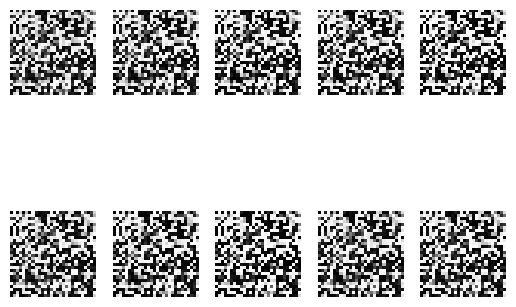

In [4]:
import matplotlib.pyplot as plt

noise = np.random.normal(0,1,(10,100))
generated = generator.predict(noise)

generated = generated.reshape(10,28,28)

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(generated[i], cmap='gray')
    plt.axis('off')

plt.show()
